# Reinforcement Learning with PPO
In this notebook, we will implement Proximal Policy Optimization (PPO) from scratch using Keras. Unlike standard Supervised Learning where we fit a model to a fixed dataset, here we train an agent to interact with a dynamic environment (a building simulation).

## Learning Objective
- **Build a PPO Training System**: Implement the Proximal Policy Optimization algorithm, a state-of-the-art method for continuous Reinforcement Learning.
- **Create Custom Keras Models for PPO**: Subclass `keras.Model` and override `train_step` to implement complex loss functions that require manual gradient calculation.
- **Implement Generalized Advantage Estimation(GAE)**: Write a Generalized Advantage Estimation function to calculate stable training targets (advantages) from raw rewards.`
- **Control Physical Systems**: Train an agent to optimize a pysical system using real-world data

## Setup

In [1]:
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from keras import layers

2026-07-30 12:15:12.978196: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785413713.004275   97484 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785413713.011915   97484 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-30 12:15:13.050846: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Loading and Normalizing Data

We are building a control system. In Control Theory terms, the Outdoor Temperature acts as an External Disturbance—a force trying to push our system away from its target state. <br>
We use the [**Jena Climate Dataset**](https://www.kaggle.com/datasets/mnassrib/jena-climate), which is sampled every 10 minutes, to drive our simulation. 

In [2]:
uri = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = keras.utils.get_file(
    origin=uri, fname="jena_climate_2009_2016.csv.zip"
)

df = pd.read_csv(zip_path)
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


Let's split the data into training and test.

In [3]:
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

Neural networks struggle with unscaled data, so let's normalize the data.

In [4]:
# Calculate stats for normalization
temp_mean = train_df["T (degC)"].mean()
temp_std = train_df["T (degC)"].std()
pres_mean = train_df["p (mbar)"].mean()
pres_std = train_df["p (mbar)"].std()

# Normalize features


def normalize_data(df):
    return np.column_stack(
        [
            df["T (degC)"].values,  # Raw Outdoor
            (df["T (degC)"].values - temp_mean) / temp_std,  # Norm Outdoor
            (df["p (mbar)"].values - pres_mean) / pres_std,  # Norm Pressure
        ]
    )


train_data_norm = normalize_data(train_df)
test_data_norm = normalize_data(test_df)

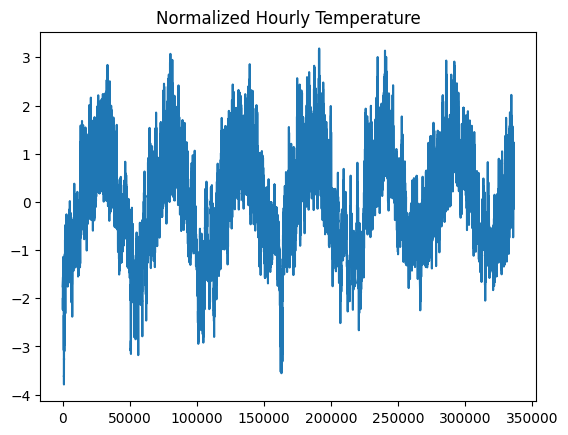

In [5]:
plt.title("Normalized Hourly Temperature")
plt.plot(train_data_norm[:, 1])
plt.show()

## Defining the Environment

In Reinforcement Learning, the "Environment" is the world the agent lives in. We build a custom Physics Simulation class (`BuildingControlEnv`) to represent a room's thermodynamics.

### The Physics Model

$$Temp_{next} = Temp_{current} + \underbrace{k \cdot (Temp_{outdoor} - Temp_{current})}_{\text{Passive Heat Loss}} + \underbrace{\text{Action} \cdot \text{HvacMaxPower}}_{\text{Active HVAC}}$$

- Insulation Factor ($k=0.1$): Represents how "leaky" the room is1. A higher value means the room temperature matches the outdoors faster.
- HVAC Power: The agent's chosen action (scaled by HVAC_POWER) adds or removes heat.


### The Reward Function (The Objective)

Designing the reward function is the most critical part of RL. We want the agent to balance two conflicting goals:
- Comfort: Keep the temperature at 22°C.
- Efficiency: Minimize electricity usage.

### Key Methods
- `reset()`: Selects a random start time from the dataset and initializes the room at 20°C .
- `step(action)`: Executes one minute of simulation. It updates the indoor temperature based on the physics model, calculates the reward, returns the next state (normalized indoor temp, outdoor temp, pressure), and increment the idx to the next timestep.

In [6]:
import numpy as np
import keras

# ==============================================================================
# Environment Configuration & Constants
# ==============================================================================
TARGET_TEMP = 22.0       # Comfortable indoor temperature target (°C)
HVAC_POWER = 5.0         # Maximum temperature change from HVAC in one step (°C)
INSULATION_FACTOR = 0.1  # Thermal insulation coefficient (passive heat transfer)
REWARD_SCALE = 0.1       # Scale factor for comfort penalties
ENERGY_COST = 0.1        # Penalty multiplier for energy consumption (action squared)

# Explicit index mapping for time-series data columns to ensure self-documentation
COL_OUTDOOR_TEMP = 0     # Index 0: Raw outdoor temperature (°C)
COL_NORM_OUTDOOR = 1     # Index 1: Normalized outdoor temperature (for state observation)
COL_NORM_PRESSURE = 2    # Index 2: Normalized atmospheric pressure (for state observation)


class BuildingControlEnv:
    """
    A simulated RL environment for smart building thermal control.
    
    The environment models a building's indoor temperature dynamics affected by 
    ambient outdoor temperature (passive heat transfer) and an HVAC system (active control).
    The goal is to maintain thermal comfort while minimizing energy consumption.
    """
    def __init__(self, data, max_steps=720, temp_mean=20.0, temp_std=10.0):
        """
        Initializes the Building Control Environment.
        
        Args:
            data: NumPy array or list of lists containing weather data.
                  Each row should contain [OutdoorTemp, NormOutdoorTemp, NormPressure].
            max_steps: Maximum duration of a training episode (in timesteps).
            temp_mean: Mean temperature used to normalize the indoor temperature.
            temp_std: Standard deviation of temperature used to normalize the indoor temperature.
        """
        self.data = data
        self.max_steps = max_steps
        self.target_temp = TARGET_TEMP
        self.insulation = INSULATION_FACTOR
        self.max_power = HVAC_POWER
        self.reward_scale = REWARD_SCALE
        self.energy_cost = ENERGY_COST
        
        # Store normalization statistics inside the instance to avoid global NameErrors
        self.temp_mean = temp_mean
        self.temp_std = temp_std
        
        self.reset()

    def reset(self, idx=None):
        """
        Resets the environment state to begin a new episode.
        
        Args:
            idx: Optional starting index in the weather dataset. 
                 If None, a valid index is selected at random.
                 
        Returns:
            The initial normalized state vector of shape (4,).
        """
        # CRITICAL FIX: Checking 'idx is None' instead of 'not idx'
        # This prevents idx=0 from mistakenly triggering the random initialization block.
        if idx is None:
            # Pick a safe random starting index in the time-series data
            # ensuring that we have enough steps remaining before the dataset ends.
            random_idx = keras.random.randint(
                [1], minval=0, maxval=len(self.data) - self.max_steps - 1
            )[0]
            
            # Safely extract Python scalar integer from the Keras backend tensor
            if hasattr(random_idx, "numpy"):
                self.idx = int(random_idx.numpy())
            else:
                self.idx = int(random_idx) # Direct fallback for JAX/PyTorch backends
        else:
            self.idx = idx

        self.step_cnt = 0
        self.indoor = 20.0       # Reset indoor temperature to a slightly cool starting temperature (°C)
        self.last_action = 0.0   # Clear the action history
        
        return self._get_state()

    def _get_state(self):
        """
        Constructs and returns the normalized environment state vector.
        
        The state features are scaled to roughly zero mean and unit variance 
        to ensure stable and rapid neural network training.
        
        Returns:
            A stacked Keras tensor of shape (4,):
            [Norm_Indoor_Temp, Norm_Outdoor_Temp, Norm_Pressure, Last_Action]
        """
        # Normalize the current indoor temperature using the saved statistics
        indoor_norm = (self.indoor - self.temp_mean) / self.temp_std
        
        # Pull the pre-normalized outdoor temperature and pressure from the data
        norm_outdoor = self.data[self.idx][COL_NORM_OUTDOOR]
        norm_pressure = self.data[self.idx][COL_NORM_PRESSURE]
        
        # Package and return as a backend-agnostic stacked tensor
        return keras.ops.stack(
            [
                indoor_norm,
                norm_outdoor,
                norm_pressure,
                self.last_action,
            ]
        )

    def _update_physics(self, action):
        """
        Executes the thermal physics simulation step.
        
        Uses Newton's Law of Cooling for passive ambient thermal transfer, 
        and adds active heat adjustment from the HVAC control action.
        
        Args:
            action: Continuous HVAC action within [-1.0, 1.0].
                    Positive represents heating, negative represents cooling.
        """
        # Retrieve the raw outdoor temperature for the physics simulation
        outdoor = self.data[self.idx][COL_OUTDOOR_TEMP]
        
        # 1. Passive Heat Transfer (Newton's Law of Cooling)
        # Heat flows from hot to cold, proportional to the temperature difference.
        self.indoor -= self.insulation * (self.indoor - outdoor)
        
        # 2. Active Thermal Control (HVAC Unit power injection)
        # Action is scaled by max_power to calculate temperature change.
        self.indoor += action * self.max_power

    def _compute_reward(self, action):
        """
        Evaluates the performance of the chosen action on the updated state.
        
        Calculates a comfort penalty based on the deviation from target temperature
        and an energy penalty proportional to the control effort.
        
        Args:
            action: Continuous HVAC action applied this step.
            
        Returns:
            A scalar representing the combined step reward.
        """
        # 1. Thermal Comfort Penalty (Quadratic error from 22.0°C target)
        error = self.indoor - self.target_temp
        comfort_penalty = -self.reward_scale * (error ** 2)
        
        # Clip the comfort penalty to prevent extreme gradients during early training
        comfort_penalty = max(comfort_penalty, -1.0)
        
        # 2. Energy Consumption Penalty (Quadratic cost on control action)
        # Quadratic scaling discourages high-amplitude oscillations and aggressive control.
        energy_penalty = -self.energy_cost * (action ** 2)
        
        return comfort_penalty + energy_penalty

    def step(self, action):
        """
        Transitions the environment by one time step based on the agent's action.
        
        Args:
            action: Continuous control input representing HVAC effort.
            
        Returns:
            next_state: The new state observation vector.
            reward: The scalar reward earned during this transition.
            done: Boolean flag indicating if the episode has finished.
            info: Dictionary containing auxiliary tracking metrics.
        """
        # Standardize continuous action clipping to [-1.0, 1.0] for physical boundaries
        action = float(np.clip(action, -1.0, 1.0))
        
        # Update the indoor environment's physical temperature
        self._update_physics(action)
        
        # Compute the step reward based on the updated indoor temperature
        reward = self._compute_reward(action)
        
        # Save action history and step forward in time
        self.last_action = action
        self.idx += 1
        self.step_cnt += 1
        
        # Check if episode has reached its terminal duration
        done = self.step_cnt >= self.max_steps
        
        # Provide debugging metrics in the standard gym 'info' dictionary
        info = {
            "raw_indoor_temp": self.indoor,
            "step_count": self.step_cnt,
        }
        
        return self._get_state(), reward, done, info

## Implementing PPO with Subclassed Keras Models

### Actor-Critic Network
To implement Proximal Policy Optimization (PPO), we need a neural network architecture that can do two very different jobs at once. We call this the Actor-Critic architecture.

- The Actor (The "Doer"):
  - Goal: Learn what to do (the Policy $\pi$).
  - Input: The State (Indoor Temp, Outdoor Temp, Pressure).
  - Output: A Gaussian distribution defined by Mean ($\mu$) and $\log \sigma$
    - **Note**: We implement log_std as a standalone trainable variable (self.add_weight) rather than a dense layer output, making it state-independent for stability 
- The Critic (The "Judge"):
  - Goal: Learn how good a state is (the Value Function $V(s)$).
  - Input: The same State as the actor.
  - Output: A single number representing the expected sum of future rewards (e.g., "This state is worth +50 points").
  - Role: The Critic's prediction is the "baseline." If the Actor gets a reward higher than the Critic predicted, we know the action was good (Positive Advantage).


### Implementation
We subclass `keras.Model` to encapsulate both networks and their custom training logic.
- `__init__`: We define two separate Sequential models (self.actor and self.critic).
- `call(inputs)`: This is the forward pass. We run the input state through both the Actor and Critic networks and return three tensors: mu, log_std, and value.
- `train_step(data)`: This is where the PPO magic happens. We override this method to customize exactly how gradients are computed. This will be used inside `model.fit()` later.
  - Since we use TensorFlow backend, we use `tf.GradientTape()` to record the forward pass.
  - We manually calculate the **PPO Clipped Loss (Actor)** and **MSE Loss (Critic)**.
  - We apply `tape.gradient` to calculate gradients for both networks simultaneously and update them with `self.optimizer`.
  
### Loss Functions
#### Actor Loss
The PPO loss is designed to improve the policy safely. It prevents the "Cliff Problem" where a single bad update destroys the agent's knowledge.

$$L^{CLIP}(\theta) = \hat{\mathbb{E}}_t [\min(r_t(\theta)\hat{A}_t, \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)\hat{A}_t)]$$
- The Ratio ($r_t$): Measures how much the new policy differs from the old one.
  - $r_t > 1$: The action is more likely now.
  - $r_t < 1$: The action is less likely now.
- The Advantage ($\hat{A}_t$): Did the action lead to a better result than expected?
- The Clip ($\epsilon=0.2$): This is the safety brake. We ignore changes that would shift the probability ratio by more than 20%. This ensures we take small, steady steps toward the optimal policy without "falling off the cliff" 

#### Critic Loss
The critic minimizes the error in reward prediction (MSE).

#### Total Loss:
We combine these two objectives, as well as the `entropy` to (A bonus for exploration) into one final number to minimize: `Total Loss = Actor_Loss + (CRITIC_WEIGHT * Critic_Loss) - (ENTROPY_WEIGHT * Entropy)`


In [7]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers

# ==========================================
# PPO Hyperparameters & Configuration
# ==========================================
CLIP_RATIO = 0.2      # PPO Trust Region (clipping parameter epsilon to prevent destructive policy updates)
ENTROPY_WEIGHT = 0.01 # Weight of the entropy bonus (higher encourages more exploration)
CRITIC_WEIGHT = 0.5   # Scaling factor for the Critic's Value MSE loss relative to the Actor's policy loss

def gaussian_log_likelihood(actions, mu, log_std):
    """
    Calculates the log probability density of continuous actions under a Gaussian distribution.
    
    Formula:
        log_pi = -0.5 * ( ((x - mu)^2 / sigma^2) + 2 * log_std + log(2 * pi) )
    
    Args:
        actions: Tensor of shape (batch_size, action_dim) representing the sampled actions.
        mu: Tensor of shape (batch_size, action_dim) representing the predicted mean.
        log_std: Tensor of shape (1, action_dim) representing the predicted log standard deviation.
        
    Returns:
        Tensor of shape (batch_size,) containing the summed log probabilities across action dimensions.
    """
    # log(2 * pi) constant used in the Gaussian probability density function (PDF)
    log_pi = keras.ops.log(2.0 * np.pi)
    
    # Recover standard deviation and variance: std = e^(log_std) and var = std^2 = e^(2 * log_std)
    std = keras.ops.exp(log_std)
    var = keras.ops.square(std)
    
    # Calculate the normalized squared difference: (x - mu)^2 / var
    squared_diff = keras.ops.square(actions - mu) / var
    
    # Evaluate the Gaussian log-likelihood formula across each individual dimension
    # 2 * log_std is equivalent to log(std^2) or log(var), representing the normalizer term
    log_prob = -0.5 * (squared_diff + 2.0 * log_std + log_pi)
    
    # Sum log probabilities across the action dimensions (axis=-1) to compute joint probability
    # returns shape: (batch_size,)
    return keras.ops.sum(log_prob, axis=-1)


class ContinuousPPO(keras.Model):
    """
    Continuous Proximal Policy Optimization (PPO) agent implemented as a subclassed Keras Model.
    This architecture supports custom train steps, manual gradient tapes, and early stopping.
    """
    def __init__(self, state_dim, action_dim):
        super().__init__()
        
        # Loss function for the Critic (minimizes the error between return targets and predicted values)
        self.critic_loss = keras.losses.MeanSquaredError()
        
        # CRITIC NETWORK (The "Judge"): Maps state to a scalar value representing expected future returns.
        # Architecture: State (state_dim) -> Dense 64 (ReLU) -> Dense 64 (Tanh) -> Dense 1 (No activation)
        self.critic = keras.Sequential(
            [
                layers.InputLayer(shape=(state_dim,)),
                layers.Dense(64, activation="relu"),
                layers.Dense(64, activation="tanh"),
                layers.Dense(1, activation=None), # Outputs V(s), shape: (batch_size, 1)
            ]
        )
        
        # ACTOR NETWORK (The "Doer"): Maps state to the mean (mu) of the action distribution.
        # Architecture: State (state_dim) -> Dense 64 (ReLU) -> Dense 64 (Tanh) -> Dense action_dim (Tanh)
        # Note: 'tanh' activation scales the mean actions strictly within [-1.0, 1.0] for physical stability.
        self.actor_mu = keras.Sequential(
            [
                layers.InputLayer(shape=(state_dim,)),
                layers.Dense(64, activation="relu"),
                layers.Dense(64, activation="tanh"),
                layers.Dense(action_dim, activation="tanh"), # Outputs mu, shape: (batch_size, action_dim)
            ]
        )
        
        # ACTOR LOG_STD (Exploration Noise): Standalone trainable parameter vector for the policy standard deviation.
        # Modeling standard deviation as state-independent significantly stabilizes learning in continuous action spaces,
        # preventing the network from collapsing exploration noise prematurely.
        self.actor_log_std = self.add_weight(
            name="log_std",
            shape=(1, action_dim),
            initializer="zeros", # Initializes log_std to 0 (which means std = e^0 = 1.0)
            trainable=True,
        )

    def call(self, inputs):
        """
        Executes a forward pass of both Actor and Critic networks.
        
        Args:
            inputs: State tensor of shape (batch_size, state_dim).
            
        Returns:
            actor_mu: predicted action mean of shape (batch_size, action_dim)
            actor_log_std: clipped log standard deviation of shape (1, action_dim)
            values: predicted state-value estimates of shape (batch_size, 1)
        """
        values = self.critic(inputs)
        actor_mu = self.actor_mu(inputs)
        
        # Clip log_std to prevent numerical overflow/underflow. 
        # log_std in [-3, 3] corresponds to standard deviation std in [0.05, 20.0]
        actor_log_std = keras.ops.clip(self.actor_log_std, -3.0, 3.0)
        
        return actor_mu, actor_log_std, values

    def ppo_loss(self, new_log_probs, old_log_probs, advantages, clip_ratio=0.2):
        """
        Calculates the Clipped Surrogate Actor Loss of PPO.
        
        Args:
            new_log_probs: Log probabilities of actions under the updated policy, shape (batch_size,).
            old_log_probs: Log probabilities of actions under the rollout policy, shape (batch_size,).
            advantages: Normalized advantages of the actions, shape (batch_size,).
            clip_ratio: The trust-region boundary (epsilon).
            
        Returns:
            A scalar tensor representing the negative Actor loss to minimize.
        """
        # Calculate the probability ratio: r_t(theta) = pi_theta(a|s) / pi_theta_old(a|s) = exp(log_new - log_old)
        ratio = keras.ops.exp(new_log_probs - old_log_probs)
        
        # Unclipped objective surrogate
        p1 = ratio * advantages
        
        # Clipped objective surrogate: limits policy change if the update moves ratio outside [1-eps, 1+epsilon]
        p2 = (
            keras.ops.clip(ratio, 1.0 - clip_ratio, 1.0 + clip_ratio)
            * advantages
        )
        
        # Compute the minimum of the clipped and unclipped objectives (pessimistic bound).
        # We apply a minus sign (-) because Keras optimizers minimize loss, whereas we want to maximize the PPO objective.
        return -keras.ops.mean(keras.ops.minimum(p1, p2))

    def entropy(self, log_std):
        """
        Calculates the Shannon Entropy of the Gaussian policy to encourage action space exploration.
        For a multivariate normal distribution with diagonal covariance, entropy is independent of the mean.
        
        Formula:
            H = 0.5 * ( log(2 * pi * e) + sum(log_std) ) = 0.5 * ( log(2 * pi) + 2 * log_std + 1 )
        """
        return keras.ops.mean(
            0.5 * (keras.ops.log(2.0 * np.pi) + 2.0 * log_std + 1.0)
        )

    def train_step(self, data):
        """
        Performs one gradient descent step over a batch of collected rollout experiences.
        Overridden to support custom PPO loss calculation and KL Divergence monitoring.
        """
        # Extract inputs and targets from the dataset dictionary
        states = data["state"]           # Shape: (batch_size, state_dim)
        actions = data["action"]         # Shape: (batch_size, action_dim)
        advantages = data["advantage"]   # Shape: (batch_size,)
        returns = data["return"]         # Shape: (batch_size,)
        old_log_probs = data["log_prob"] # Shape: (batch_size,)

        with tf.GradientTape() as tape:
            # 1. Forward Pass
            mu, log_std, values = self(states)
            
            # 2. Compute Action Log-Probabilities under the current model parameters
            new_log_probs = gaussian_log_likelihood(actions, mu, log_std)
            
            # 3. Calculate Actor Loss (Clipped Surrogate Policy Loss)
            actor_loss = self.ppo_loss(
                new_log_probs, old_log_probs, advantages, CLIP_RATIO
            )
            
            # 4. CRITICAL FIX: Ensure 'returns' and 'values' have identical shapes.
            # In Keras, if 'returns' has shape (batch_size,) and 'values' has shape (batch_size, 1),
            # computing MeanSquaredError will trigger an implicit broadcasting error, converting them 
            # to a (batch_size, batch_size) matrix before calculating the mean, producing an incorrect, inflated loss.
            returns_reshaped = keras.ops.expand_dims(returns, axis=-1)
            critic_loss = self.critic_loss(returns_reshaped, values)
            
            # 5. Compute Policy Entropy Bonus
            entropy = self.entropy(log_std)
            
            # 6. Compute Approximate KL Divergence for early stopping diagnostics.
            # Using the estimator: KL ~= (ratio - 1) - log_ratio. This estimator is always positive and low-variance.
            log_ratio = new_log_probs - old_log_probs
            ratio = keras.ops.exp(log_ratio)
            approx_kl = keras.ops.mean((ratio - 1.0) - log_ratio)
            
            # 7. Total Loss computation
            # Total Loss = Actor_Loss + (w_c * Critic_Loss) - (w_e * Entropy)
            # Subtracting entropy maximizes it, which penalizes overly deterministic policies and maintains exploration.
            total_loss = (
                actor_loss
                + (CRITIC_WEIGHT * critic_loss)
                - (ENTROPY_WEIGHT * entropy)
            )

        # 8. Gradient updates: Compute and apply gradients using Keras operations
        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        # Return metric dictionary for monitoring and callbacks (e.g., KLEarlyStopping)
        return {
            "actor": actor_loss,
            "critic": critic_loss,
            "ent": entropy,
            "kl": approx_kl,
        }


## Define Generalized Advantage Estimation (GAE)

In Reinforcement Learning, looking at a single reward isn't enough. We need to know if a good result was just luck (noise) or part of a winning streak (signal).  **GAE** combines two pieces of information to measure this "momentum":

**The Inputs (What we know)**

These are the raw materials we feed into the GAE calculation:
- `values` (The Expectation): What the Critic predicted would happen.
  - Analogy: "I expect to get a 70 on this exam."
- `rewards` (The Reality): What actually happened in the environment.
  - Analogy: "I actually got a 90."
- `next_value` (The Horizon): The Critic's prediction for the state after the current batch ends. This connects our current experience to the future.

**The Outputs (What we use in training)**

These are the calculated signals used to update our neural networks:
- `advantages` (The Bonus $\rightarrow$ Trains the Actor): How much better was the action than expected?
  - Formula: `Accumulated Surprise` (Immediate difference + discounted future difference).
  - Meaning: If positive, the agent is performing above baseline. Do this action more.
- `returns` (The Truth $\rightarrow$ Trains the Critic): What was the actual total value of the state, in hindsight?
  - Formula: Advantage + Value
  - Meaning: The Critic was wrong. Next time, it should predict this number instead.

**The Calculation Logic**

GAE uses two steps to process these inputs:
- **Calculate Delta ($\delta$)**: The immediate surprise for one step.
  - `Delta = (Reward + Future Value) - Current Value`
- **Calculate Advantage**: The rolling surprise.
  - It looks backwards: A success tomorrow helps justify the action taken today.

In [8]:
GAMMA = 0.99  # Discount factor
LAMBDA = 0.95  # GAE smoothing


def gae(rewards, values, next_value):
    advantages = np.zeros_like(rewards)
    last_gae = 0.0

    next_values = np.concatenate((values[1:], [next_value]), axis=0)

    # Bellman Error (Deltas) = r + gamma * V(next) - V(current)
    deltas = rewards + (GAMMA * next_values) - values

    decay = GAMMA * LAMBDA
    # Iterate backwards
    for t in reversed(range(len(rewards))):
        # Recursive GAE Formula
        advantages[t] = last_gae = deltas[t] + decay * last_gae

    returns = advantages + values
    return advantages, returns

Let's check how GAE works using an example:
- Scenario: You have a goose.
- Expectation (Values): You think it lays regular eggs (Worth \$2).
- Reality (Rewards): It actually lays GOLDEN eggs (Worth \$10).

In [9]:
rewards = [10.0, 10.0, 10.0, 10.0, 10.0]  # Reality: It pays $10 daily
values = [2.0, 2.0, 2.0, 2.0, 2.0]  # Expectation: We expected only $2
next_value = 2.0  # Future expectation is also $2

advantages, returns = gae(rewards, values, next_value)

print(f"Calculated Advantage (GAE): \n{np.round(advantages, 2)}")
print(f"\nCorrected Truth (Returns):  \n{np.round(returns, 2)}")

print(
    f"\nDay 1 Return ({returns[0]:.2f}):    The goose is actually worth ${returns[0]:.2f} total."
)
print(
    f"Day 1 Advantage ({advantages[0]:.2f}): But since you expected ${values[0]}, the 'Good Surprise' is only ${advantages[0]:.2f}."
)

Calculated Advantage (GAE): 
[44.3  36.5  28.19 19.37  9.98]

Corrected Truth (Returns):  
[46.3  38.5  30.19 21.37 11.98]

Day 1 Return (46.30):    The goose is actually worth $46.30 total.
Day 1 Advantage (44.30): But since you expected $2.0, the 'Good Surprise' is only $44.30.


## PPO Training

We use a standard Python loop for data collection (the "Rollout"), but we use `model.fit()` for the optimization phase. 

### Custom Callback
KLEarlyStopping Callback: PPO is sensitive to large policy updates. If the new policy deviates too far from the old one (measured by KL Divergence), performance collapses.

We implement a custom Callback that checks KL Divergence at the end of every epoch.

If `kl > target_kl` (typically between 0.01-0.05), we set `self.model.stop_training = True`, instantly aborting the update for that batch to save the policy.

In [10]:
# ==============================================================================
# 1. Helper Class: KL Early Stopping Callback
# ==============================================================================
class KLEarlyStopping(keras.callbacks.Callback):
    """
    Keras callback that monitors the Approximate KL Divergence during training.
    If the policy updates move too far from the old policy (exceeding target_kl),
    it halts training for the current rollout to prevent policy collapse.
    """
    def __init__(self, target_kl=0.025):
        super().__init__()
        self.target_kl = target_kl

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        approx_kl = logs.get("kl")
        
        # Stop training if the policy diverges beyond our safety threshold
        if approx_kl is not None and approx_kl > self.target_kl:
            print(f"\n        Epoch {epoch+1:02d}: Early stopping triggered. "
                  f"KL Divergence ({approx_kl:.4f}) exceeded target ({self.target_kl:.4f})")
            self.model.stop_training = True

### The Training Loop: Rollout & Update

Training a PPO agent is different from standard Deep Learning. Since PPO is an **on-policy** method, we cannot simply pass a static dataset to `model.fit()`. Instead, we must generate our own data on the fly.

The training process is a cycle that repeats for a set number of Rollouts (iterations). Each rollout consists of three distinct phases:

#### Phase 1: Data Collection
We interact with the environment to collect a batch of fresh experience. PPO is an **On-Policy algorithm**, meaning it can only learn from data generated by its current policy. Old data is discarded.

We repeat these steps (see the inner for loop below) for STEPS_PER_ROLLOUT (lenght of one rollout episode) times:
1. **Observe & Predict**: The agent sees the current state, and the Actor network outputs a mean action ($\mu$) and a standard deviation ($\sigma$).
2. **Sample**: We sample an action from this Gaussian distribution. This adds randomness, allowing the agent to discover new strategies 
3. **Act**: We apply this action to the environment (`env.step`) and receive a **Reward** and the **Next State** 
4. **Store**: We save the State, Action, Reward, and Value Prediction into a temporary buffer 

#### Phase 2: Processing
Once the rollout is complete, we pause to analyze what happened. This is where we calculate the **Generalized Advantage Estimation (GAE)** we defined above. This converts our raw experience into high-quality training targets for the neural network.

#### Phase 3: Training
Now we update the neural network using the processed data.

We call `model.fit()` to run the PPO Loss function we defined earlier. <br>
We train on this specific batch of data for multiple epochs to squeeze out as much learning as possible, but the `KLEarlyStopping` callback watches over this phase to ensure the policy doesn't overfit and remains stable.

In [11]:
%%time
import numpy as np
import keras


# # ==============================================================================
# # 2. Helper Function: Generalized Advantage Estimation (GAE)
# # ==============================================================================
def calculate_gae(rewards, values, last_val, gamma=0.99, lam=0.95):
    """
    Computes Generalized Advantage Estimations (GAE) and TD targets (returns).
    
    Args:
        rewards: List of step rewards of length N.
        values: List of value estimates of length N.
        last_val: Scalar value estimate of the terminal state S_N.
        gamma: Discount factor (importance of future rewards).
        lam: GAE bias-variance trade-off parameter.
        
    Returns:
        advantages: Tensor of shape (N,) normalized for policy gradient stability.
        returns: Tensor of shape (N,) representing TD-target return values.
    """
    n = len(rewards)
    advantages = np.zeros(n, dtype=np.float32)
    last_gae_lam = 0.0
    
    # Trace backward from the final step of the rollout
    for t in reversed(range(n)):
        next_value = values[t + 1] if t + 1 < n else last_val
        
        # 1. TD Error (delta_t): r_t + gamma * V(s_t+1) - V(s_t)
        delta = rewards[t] + gamma * next_value - values[t]
        
        # 2. GAE (A_t): delta_t + (gamma * lambda) * A_{t+1}
        advantages[t] = last_gae_lam = delta + gamma * lam * last_gae_lam
        
    # Temporal Difference Target Returns: Q(s, a) = GAE + V(s)
    returns = advantages + np.array(values, dtype=np.float32)
    
    # Convert to Keras backend tensors
    return keras.ops.convert_to_tensor(advantages), keras.ops.convert_to_tensor(returns)


# ==============================================================================
# 3. Main PPO Training Loop
# ==============================================================================
# Training Hyperparameters
ROLLOUTS = 50                 # Total training epochs (Outer Loop)
STEPS_PER_ROLLOUT = 1008      # Rollout buffer size per epoch (1008 steps = exactly 1 week)
MAX_EPOCHS_PER_ROLLOUT = 50   # Max gradient steps per rollout buffer (Inner Loop)
BATCH_SIZE = 32               # Mini-batch size for optimizer step
LR = 0.0003                   # Adam Learning Rate
TARGET_KL = 0.025             # Early stopping KL Divergence threshold

# Environment & Model Initialization
env_train = BuildingControlEnv(train_data_norm, max_steps=STEPS_PER_ROLLOUT)
model = ContinuousPPO(state_dim=4, action_dim=1)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR, global_clipnorm=0.5)
)

print("Starting Training...")

# Training history dictionary for metric visualization
history = {
    "actor": [],
    "critic": [],
    "ent": [],
    "rewards": [],
}

for rollout in range(ROLLOUTS):
    # ==========================================
    # Phase 1: Data Collection (Rollout Buffer)
    # ==========================================
    print(f"    Starting Rollout {rollout + 1}/{ROLLOUTS}...")
    
    # Initialize buffers
    states_buf, actions_buf, rewards_buf, values_buf, log_probs_buf = [], [], [], [], []
    
    state = env_train.reset()
    
    for step in range(STEPS_PER_ROLLOUT):
        # Format state observation into a batch of size 1: shape (1, 4)
        state_input = keras.ops.expand_dims(state, axis=0)
        
        # 1. Forward Pass: Query actor distribution and critic value
        mu, log_std, value_est = model(state_input)
        
        # 2. Sample Action: Exploration via Gaussian noise scaling
        std = keras.ops.exp(log_std)
        action_sample = mu + std * keras.random.normal(keras.ops.shape(mu))
        
        # 3. Compute Log Probability Density of the chosen action
        log_prob = gaussian_log_likelihood(action_sample, mu, log_std)
        
        # Extract scalar Python values from backend tensors safely
        action_scalar = float(action_sample.numpy()[0, 0])
        value_scalar = float(value_est.numpy()[0, 0])
        log_prob_scalar = float(log_prob.numpy()[0])
        
        # 4. Environment Step: Transition state based on physical action
        # CRITICAL BUG FIX: Unpacks 4 values (next_state, reward, done, info) to match refined Gym API
        next_state, reward, done, info = env_train.step(action_scalar)
        
        # Store rollout observations
        states_buf.append(state)
        actions_buf.append(action_scalar)
        rewards_buf.append(reward)
        values_buf.append(value_scalar)
        log_probs_buf.append(log_prob_scalar)
        
        state = next_state
        
    # ==========================================
    # Phase 2: Processing (GAE & Normalization)
    # ==========================================
    # Bootstrap the final state's value estimate (to handle non-terminal trajectory truncations)
    state_input_last = keras.ops.expand_dims(state, axis=0)
    _, _, last_val_est = model(state_input_last)
    last_val_scalar = float(last_val_est.numpy()[0, 0])
    
    # Compute GAE advantages and target returns
    advantages, returns = calculate_gae(
        rewards_buf, values_buf, last_val_scalar, gamma=0.99, lam=0.95
    )
    
    # Advantage Normalization: Dramatically reduces gradient variance across the batch
    advantages = (advantages - keras.ops.mean(advantages)) / (
        keras.ops.std(advantages) + 1e-8
    )
    
    # CRITICAL ALGORITHMIC FIX: Removed return normalization.
    # Normalizing return targets across rolling batches obscures absolute reward scales,
    # preventing the Critic from converging on a stable value baseline.
    
    # ==========================================
    # Phase 3: Policy Optimization (Training)
    # ==========================================
    # Stack list of tensors cleanly into single batch tensors before passing to fit()
    dataset = {
        "state": keras.ops.stack(states_buf, axis=0),
        "action": np.array(actions_buf).reshape(-1, 1),
        "advantage": advantages,
        "return": returns,
        "log_prob": np.array(log_probs_buf),
    }
    
    # Run gradient updates with callback monitoring for KL Divergence limits
    rollout_history = model.fit(
        dataset,
        batch_size=BATCH_SIZE,
        epochs=MAX_EPOCHS_PER_ROLLOUT,
        verbose=0,
        callbacks=[KLEarlyStopping(target_kl=TARGET_KL)],
    )
    
    # Log averages across the current optimization trajectory
    history["actor"].append(float(keras.ops.mean(rollout_history.history["actor"]).numpy()))
    history["critic"].append(float(keras.ops.mean(rollout_history.history["critic"]).numpy()))
    history["ent"].append(float(keras.ops.mean(rollout_history.history["ent"]).numpy()))
    history["rewards"].append(float(keras.ops.sum(rewards_buf).numpy()))
    
    print(f"        Rollout {rollout+1:02d} Complete - Total Reward: {history['rewards'][-1]:.2f}")

2026-07-30 12:15:21.306599: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Starting Training...
    Starting Rollout 1/50...

        Epoch 08: Early stopping triggered. KL Divergence (0.0353) exceeded target (0.0250)
        Rollout 01 Complete - Total Reward: -971.16
    Starting Rollout 2/50...

        Epoch 10: Early stopping triggered. KL Divergence (0.0269) exceeded target (0.0250)
        Rollout 02 Complete - Total Reward: -899.14
    Starting Rollout 3/50...

        Epoch 03: Early stopping triggered. KL Divergence (0.0466) exceeded target (0.0250)
        Rollout 03 Complete - Total Reward: -989.89
    Starting Rollout 4/50...

        Epoch 12: Early stopping triggered. KL Divergence (0.0307) exceeded target (0.0250)
        Rollout 04 Complete - Total Reward: -824.00
    Starting Rollout 5/50...

        Epoch 11: Early stopping triggered. KL Divergence (0.0261) exceeded target (0.0250)
        Rollout 05 Complete - Total Reward: -749.11
    Starting Rollout 6/50...

        Epoch 10: Early stopping triggered. KL Divergence (0.0738) exceeded tar

## Evaluation

After training, we switch the model to inference mode.

During training, we sampled actions from a Gaussian distribution (exploration). For evaluation, we use the mean mu directly (exploitation) to check the optimal performance.

In [12]:
TEST_STEPS = 2000

# Initialize the evaluation environment
test_env = BuildingControlEnv(test_data_norm, max_steps=TEST_STEPS)
state = test_env.reset()

# Lists to store logged variables for visualization
indoor_log, outdoor_log, action_log = [], [], []

for t in range(TEST_STEPS):
    # Formats state into batch dimension (1, state_dim) for the neural network input
    state_input = keras.ops.expand_dims(state, axis=0)
    
    # 1. Use Mean (mu) for deterministic evaluation (unpacking model's 3 outputs)
    mu, _, _ = model(state_input, training=False)
    action = mu.numpy()[0, 0]

    # 2. Unpack all 4 values returned by test_env.step(action)
    state, reward, done, info = test_env.step(action)

    # 3. Log the physical indoor temperature directly from the environment
    indoor_log.append(test_env.indoor)

    # 4. Extract and denormalize the outdoor temperature for plotting.
    outdoor_norm = float(state[1].numpy()) if hasattr(state[1], "numpy") else float(state[1])
    outdoor_real = (outdoor_norm * temp_std) + temp_mean
    
    outdoor_log.append(outdoor_real)
    action_log.append(action)
    
    # Optional safety check: reset the environment if an episode boundary is hit
    if done:
        state = test_env.reset()


Let's plot the Indoor Temp controlled by HVAC actions vs. Target Temp to visually verify if the agent learned to anticipate weather changes.

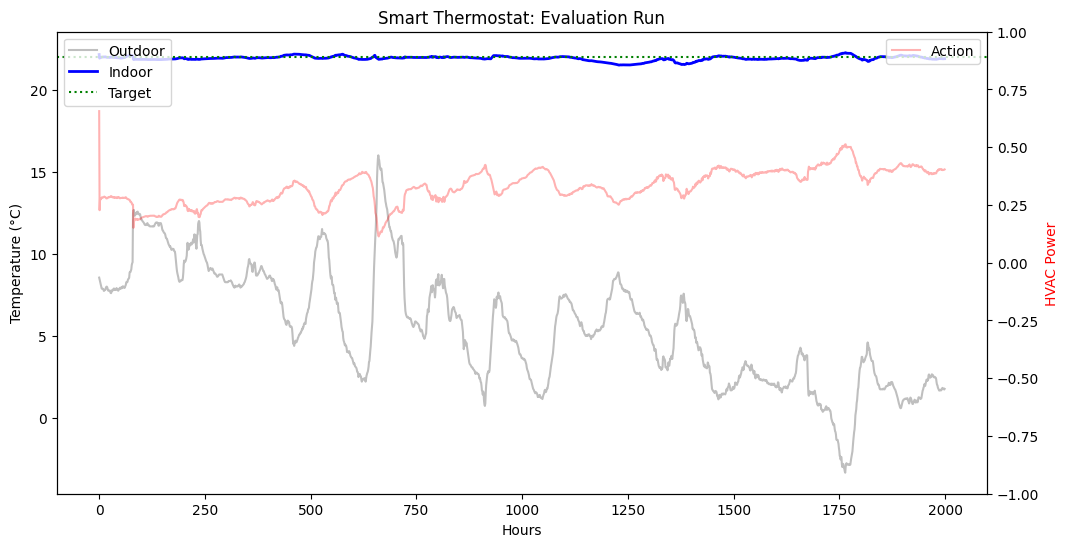

In [13]:
# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel("Hours")
ax1.set_ylabel("Temperature (°C)")
ax1.plot(outdoor_log, color="gray", alpha=0.5, label="Outdoor")
ax1.plot(indoor_log, color="blue", linewidth=2, label="Indoor")
ax1.axhline(y=TARGET_TEMP, color="green", linestyle=":", label="Target")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.set_ylabel("HVAC Power", color="red")
ax2.plot(action_log, color="red", alpha=0.3, label="Action")
ax2.set_ylim(-1.0, 1.0)
ax2.legend(loc="upper right")

plt.title("Smart Thermostat: Evaluation Run")
plt.show()

In [14]:
import datetime
import os
import shutil
OUTPUT_DIR = "./rl_ppo_export"
shutil.rmtree(OUTPUT_DIR, ignore_errors=True)
TIMESTAMP = datetime.datetime.now().strftime("%Y%m%d%H%M%S")

EXPORT_PATH = os.path.join(OUTPUT_DIR, TIMESTAMP)

SAVEDMODEL_PATH = os.path.join(EXPORT_PATH, "savedmodel")
KERAS_PATH = os.path.join(EXPORT_PATH, "model.keras")

model.export(SAVEDMODEL_PATH)
#model.save(KERAS_PATH)

INFO:tensorflow:Assets written to: ./rl_ppo_export/20260730122615/savedmodel/assets


INFO:tensorflow:Assets written to: ./rl_ppo_export/20260730122615/savedmodel/assets


Saved artifact at './rl_ppo_export/20260730122615/savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Output Type:
  Tuple[TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(1, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  140366065102928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140366065106576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140366065105232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140366065104848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140366065105424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140366065104656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140366062322704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140366062323472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140366062322512: TensorSpec(s

In [15]:
# ==============================================================================
# 1. Initialization and Constants
# ==============================================================================
PROJECT = !gcloud config get-value project 2>/dev/null
PROJECT = PROJECT[0]
PROJECT_ID = PROJECT
BUCKET = PROJECT
REGION = "us-central1"
MODEL_DISPLAYNAME = f"rl-ppo-{TIMESTAMP}"

print(f"MODEL_DISPLAYNAME: {MODEL_DISPLAYNAME}")

os.environ["BUCKET"] = BUCKET
os.environ["REGION"] = REGION

MODEL_DISPLAYNAME: rl-ppo-20260730122615


In [16]:
%%bash
# Create GCS bucket if it doesn't exist already...
exists=$(gsutil ls -d | grep -w gs://${BUCKET}/)

if [ -n "$exists" ]; then
    echo -e "Bucket exists, let's not recreate it."
else
    echo "Creating a new GCS bucket."
    gsutil mb -l ${REGION} gs://${BUCKET}
    echo "\nHere are your current buckets:"
    gsutil ls
fi

Bucket exists, let's not recreate it.


In [17]:
!gsutil cp -R $SAVEDMODEL_PATH gs://$BUCKET/$MODEL_DISPLAYNAME

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file://./rl_ppo_export/20260730122615/savedmodel/saved_model.pb [Content-Type=application/octet-stream]...
Copying file://./rl_ppo_export/20260730122615/savedmodel/fingerprint.pb [Content-Type=application/octet-stream]...
Copying file://./rl_ppo_export/20260730122615/savedmodel/variables/variables.data-00000-of-00001 [Content-Type=application/octet-stream]...
Copying file://./rl_ppo_export/20260730122615/savedmodel/variables/variables.index [Content-Type=application/octet-stream]...
/ [4 files][160.2 KiB/160.2 KiB]                                                
Operation completed over 4 objects/160.2 KiB.                                    


## Create and Deploy to an Endpoint

After uploading, `uploaded_model.deploy` creates an endpoint and deploys the model to it. An endpoint is a dedicated Agent Platform resource for serving predictions. Parameters include machine_type (machine resources) and accelerator_type/accelerator_count (for GPU acceleration).

**The deployment takes around 10 minutes.**

In [18]:
import os
from google.cloud import aiplatform

# ==============================================================================
# 1. Initialization and Constants
# ==============================================================================
BUCKET_URI = f"gs://{BUCKET}/{MODEL_DISPLAYNAME}"  # Change to your GCS directory

# Use Google's pre-built prediction container matching your Keras/TensorFlow version
TF_PREDICTION_CONTAINER = "us-docker.pkg.dev/vertex-ai/prediction/tf2-cpu.2-15:latest"

print("📌 Initializing Vertex AI SDK...")
aiplatform.init(project=PROJECT_ID, location=REGION)

# ==============================================================================
# 2. Register Model inside the Model Registry
# ==============================================================================
# Note: Ensure your Keras model has been exported to BUCKET_URI as a "SavedModel"
# directory (which contains the 'saved_model.pb' file and 'variables/' folder).
print("📌 Registering model in Vertex AI Model Registry...")
model = aiplatform.Model.upload(
    display_name="building-control-ppo-model",
    artifact_uri=BUCKET_URI,
    serving_container_image_uri=TF_PREDICTION_CONTAINER,
    description="Continuous PPO model for Smart Building thermal control."
)
print(f"✔️ Model registered successfully!")
print(f"   Model Resource Name: {model.resource_name}")

# ==============================================================================
# 3. Create the Serving Endpoint
# ==============================================================================
print("📌 Creating managed Vertex AI Endpoint...")
endpoint = aiplatform.Endpoint.create(
    display_name="building-control-ppo-endpoint",
    description="Live HTTP endpoint for real-time temperature control policies."
)
print(f"✔️ Endpoint created successfully!")
print(f"   Endpoint Resource Name: {endpoint.resource_name}")

# ==============================================================================
# 4. Deploy the Model to the Endpoint
# ==============================================================================
print("📌 Deploying model to Endpoint (this might take 3 to 10 minutes)...")
deployed_model = model.deploy(
    endpoint=endpoint,
    deployed_model_display_name="building-control-ppo-v1",
    machine_type="n1-standard-2", # Cost-effective default instance
    min_replica_count=1,          # Minimum nodes for high-availability
    max_replica_count=2,          # Max node scaling limit under high traffic
)
print("\n🎉 Success! Your model is now fully deployed and serving live traffic.")
print(f"👉 Public Endpoint API URL: https://{REGION}-aiplatform.googleapis.com/v1/{endpoint.resource_name}:predict")


/home/jupyter/asl-ml-immersion/asl_core/.venv/lib/python3.12/site-packages/google/cloud/aiplatform/models.py:52: FutureWarning: Support for google-cloud-storage < 3.0.0 will be removed in a future version of google-cloud-aiplatform. Please upgrade to google-cloud-storage >= 3.0.0.
  from google.cloud.aiplatform.utils import gcs_utils


📌 Initializing Vertex AI SDK...
📌 Registering model in Vertex AI Model Registry...
✔️ Model registered successfully!
   Model Resource Name: projects/813476375076/locations/us-central1/models/2024702833793695744
📌 Creating managed Vertex AI Endpoint...
✔️ Endpoint created successfully!
   Endpoint Resource Name: projects/813476375076/locations/us-central1/endpoints/6467525856427245568
📌 Deploying model to Endpoint (this might take 3 to 10 minutes)...

🎉 Success! Your model is now fully deployed and serving live traffic.
👉 Public Endpoint API URL: https://us-central1-aiplatform.googleapis.com/v1/projects/813476375076/locations/us-central1/endpoints/6467525856427245568:predict


In [19]:
ENDPOINT_ID = endpoint.resource_name

Once deployed, the model is accessible for online prediction requests. 

The key within this JSON object must match the input tensor's name in your model's serving signature. 
For instance, if your model's input layer is named `'input_layer'`, your JSON input would look like `{"input_layer": [...]}`, and the each data point needs to be shaped in (4,).  This ensures the prediction service correctly maps your input data to the expected model input.

🔄 Step 1: Programmatically auto-detecting GCP environment...
   👉 Detected GCP Project ID: 'qwiklabs-asl-04-3460f3cf1646'
   👉 Servicing Region:         'us-central1'

🔄 Step 2: Querying active endpoint metadata...
   👉 Found active Endpoint: 'building-control-ppo-endpoint'
   👉 Numeric Endpoint ID:   '6467525856427245568'
   👉 Force-loading connection to prevent path validation conflicts...
   ✔️ Connection successfully established and synced!

🔄 Step 3: Starting Online Inference Evaluation Loop (2000 steps)...
   [Step 0001/2000] Querying optimal action from Vertex AI...
   [Step 0100/2000] Querying optimal action from Vertex AI...
   [Step 0200/2000] Querying optimal action from Vertex AI...
   [Step 0300/2000] Querying optimal action from Vertex AI...
   [Step 0400/2000] Querying optimal action from Vertex AI...
   [Step 0500/2000] Querying optimal action from Vertex AI...
   [Step 0600/2000] Querying optimal action from Vertex AI...
   [Step 0700/2000] Querying optimal action from

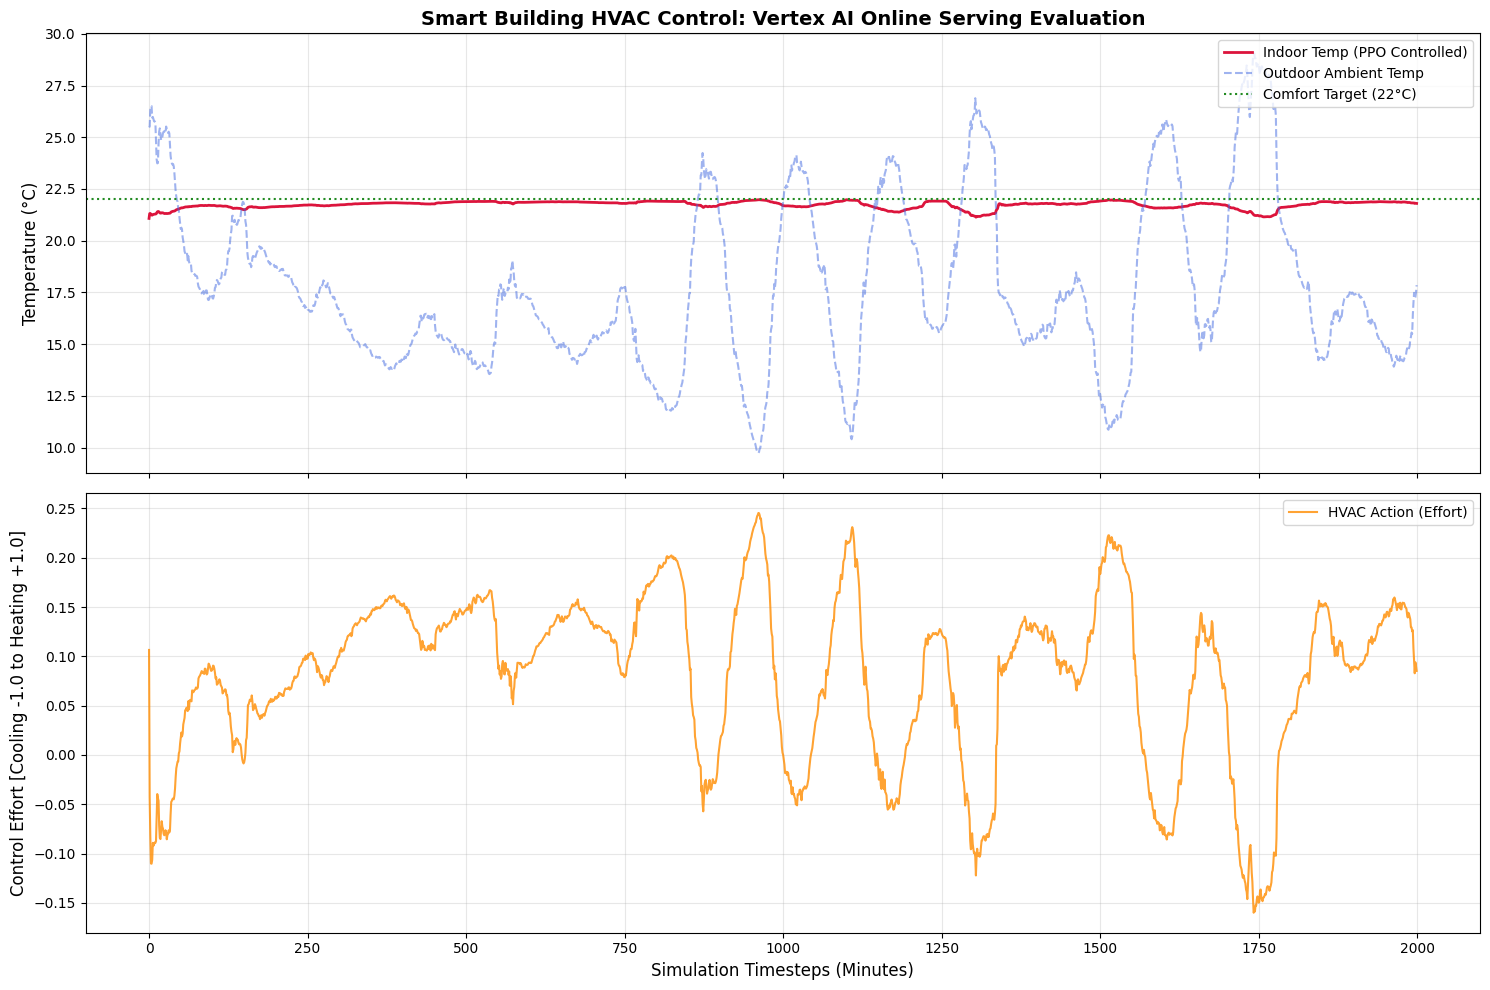

🎉 Success! Your model evaluation is complete.


In [20]:
import os
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import google.auth
from google.cloud import aiplatform
import keras

# ==============================================================================
# 1. PROGRAMMATIC PROJECT AUTO-DISCOVERY & SDK INITIALIZATION
# ==============================================================================
print("🔄 Step 1: Programmatically auto-detecting GCP environment...")

# Auto-detect the active sandbox Project ID (e.g., qwiklabs-asl-...)
try:
    _, detected_project_id = google.auth.default()
except Exception:
    detected_project_id = None

if not detected_project_id:
    try:
        detected_project_id = subprocess.check_output(
            "gcloud config get-value project", shell=True
        ).decode().strip()
    except Exception:
        # Fallback to the discovered active project ID if detection fails
        detected_project_id = PROJECT

LOCATION = "us-central1"

print(f"   👉 Detected GCP Project ID: '{detected_project_id}'")
print(f"   👉 Servicing Region:         '{LOCATION}'")

# Initialize Vertex AI SDK
aiplatform.init(project=detected_project_id, location=LOCATION)

# ==============================================================================
# 2. ROBUST VERTEX AI ENDPOINT FORCE-LOADING
# ==============================================================================
print("\n🔄 Step 2: Querying active endpoint metadata...")
endpoints = aiplatform.Endpoint.list(filter='display_name="building-control-ppo-endpoint"')

if not endpoints:
    # General fallback scan
    endpoints = aiplatform.Endpoint.list()

if endpoints:
    numeric_id = endpoints[0].name
    print(f"   👉 Found active Endpoint: '{endpoints[0].display_name}'")
    print(f"   👉 Numeric Endpoint ID:   '{numeric_id}'")
    
    # Force-load using numeric ID and active Project ID string mapping.
    # This bypasses the Project Number 400 Invalid Argument path validation bug.
    print("   👉 Force-loading connection to prevent path validation conflicts...")
    endpoint = aiplatform.Endpoint(endpoint_name=numeric_id)
    print(f"   ✔️ Connection successfully established and synced!")
else:
    raise ValueError(
        f"❌ No deployed endpoints found in project '{detected_project_id}'. "
        f"Please verify that your deployment cell has completed successfully."
    )

# ==============================================================================
# 3. EVALUATION SIMULATION RUN
# ==============================================================================
TEST_STEPS = 2000
print(f"\n🔄 Step 3: Starting Online Inference Evaluation Loop ({TEST_STEPS} steps)...")

# Initialize your custom Gym-compatible building thermal environment
test_env = BuildingControlEnv(test_data_norm, max_steps=TEST_STEPS)
state = test_env.reset()

# Pre-allocate arrays for logging metrics and visualization
indoor_log = []
outdoor_log = []
action_log = []

for t in range(TEST_STEPS):
    # Progress monitor (logs progress every 100 steps)
    if (t + 1) % 100 == 0 or t == 0:
        print(f"   [Step {t+1:04d}/{TEST_STEPS}] Querying optimal action from Vertex AI...")

    # A. PAYLOAD SANITIZATION (EagerTensor -> list of float values)
    state_list = np.array(state).tolist()  # Strips TensorFlow wrappers to ensure JSON-serializability
    instances = [state_list]               # Packs into batch dimension of size 1

    # B. CALL DEPLOYED MODEL ENDPOINT
    response = endpoint.predict(instances=instances)
    
    # C. ROBUST MULTI-OUTPUT SIGNATURE PARSING
    prediction = response.predictions[0]
    
    if isinstance(prediction, dict):
        # Search for Keras' default mapped output signature key representing the Actor Mean (mu)
        possible_keys = ["output_0", "actor_mu", "mu"]
        mu_val = None
        for key in possible_keys:
            if key in prediction:
                mu_val = prediction[key]
                break
        if mu_val is None:
            first_key = list(prediction.keys())[0]
            mu_val = prediction[first_key]
    else:
        # Fallback if served as a nested flat list
        mu_val = prediction[0]

    # Convert the extracted mean action to a scalar float
    action = float(mu_val[0]) if isinstance(mu_val, list) else float(mu_val)

    # D. SIMULATE STEP (unpacking 4 Gym-standard parameters)
    state, reward, done, info = test_env.step(action)

    # E. RECORD DATA & DENORMALIZE OUTDOOR TEMP
    indoor_log.append(test_env.indoor)

    # Unpack normalized outdoor temp (index 1 of state) and scale back to Celsius
    outdoor_norm = float(np.array(state[1]))
    outdoor_real = (outdoor_norm * temp_std) + temp_mean
    
    outdoor_log.append(outdoor_real)
    action_log.append(action)
    
    # If the episode length completes before the test limit, reset and continue tracking
    if done:
        state = test_env.reset()

print("\n🎉 Step 3 Complete: All physical thermal metrics have been successfully logged!")

# ==============================================================================
# 4. DATA VISUALIZATION
# ==============================================================================
print("\n🔄 Step 4: Generating publication-grade performance charts...")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Top Subplot: Thermal Control Performance
ax1.plot(indoor_log, label="Indoor Temp (PPO Controlled)", color="crimson", linewidth=2)
ax1.plot(outdoor_log, label="Outdoor Ambient Temp", color="royalblue", alpha=0.5, linestyle="--")
ax1.axhline(y=22.0, color="forestgreen", linestyle=":", label="Comfort Target (22°C)")
ax1.set_ylabel("Temperature (°C)", fontsize=12)
ax1.set_title("Smart Building HVAC Control: Vertex AI Online Serving Evaluation", fontsize=14, fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right", frameon=True, facecolor="white")

# Bottom Subplot: HVAC Control Effort (Actions)
ax2.plot(action_log, label="HVAC Action (Effort)", color="darkorange", linewidth=1.5, alpha=0.8)
ax2.set_ylabel("Control Effort [Cooling -1.0 to Heating +1.0]", fontsize=12)
ax2.set_xlabel("Simulation Timesteps (Minutes)", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right", frameon=True, facecolor="white")

plt.tight_layout()
plt.show()

print("🎉 Success! Your model evaluation is complete.")


## Cleanup

When deploying a model to an endpoint for online prediction, the minimum `min-replica-count` is 1, and it is charged per node hour. So let's delete the endpoint to reduce unnecessary charges. Before we can delete the endpoint, we first undeploy all attached models... 

In [ ]:
#endpoint.undeploy_all()
#endpoint.delete()

Copyright 2025 Google LLC

Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at

https://www.apache.org/licenses/LICENSE-2.0
Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.